# Clasificadores Bayesianos

El objetivo es construir paso a paso un clasificador bayesiano para reconocer dígitos manuscritos y, a partir de esa construcción, introducir el clasificador **Naive Bayes Gaussiano**.

La práctica sigue dos ideas centrales:

- primero se trabaja con **una única característica** para poder visualizar todas las probabilidades involucradas
- luego se incorporan **dos características** para introducir el supuesto de independencia condicional de Naive Bayes.

In [6]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from IPython.display import Image, display
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

figure_dir = './AM_NaiveBayes/2_imagenes/'


# 1. Clasificador de Bayes

El clasificador de Bayes aborda la clasificación desde un **modelo probabilístico**.

Para una muestra $x$, estima la probabilidad de pertenencia a cada clase y toma la decisión utilizando esas probabilidades.

# 2. Conceptos de probabilidad fundamentales para clasificación

Antes de construir el clasificador, revisaremos las cantidades que aparecen en la regla de Bayes.

### Probabilidad a priori $P(w_i)$

Representa la probabilidad de observar la clase $w_i$ **antes de conocer el valor de la muestra**.

En un conjunto de entrenamiento puede estimarse como la proporción de ejemplos de esa clase.

***Ej. Cuál es la probabilidad de encontrar individuos anémicos en una población de individuos anémicos + sanos***

### Probabilidad condicional $p(x\mid w_i)$ — *likelihood*

Indica qué tan compatible es observar el valor $x$ si sabemos que la muestra pertenece a la clase $w_i$.

Para variables continuas, como la característica que usaremos en esta práctica, trabajaremos con una **función de densidad de probabilidad**.

***Ej. Tengo 2 grupos etiquetados con sanos y anémicos, cuál es la probabilidad de sacar un conteo de glóbulos rojos 2.000.000, conociendo la clase a la que pertenece la muestra.***

### Densidad conjunta $p(x,w_i)$

Probabilidad de observar la muestra $x$ con la etiqueta $w_i$

Combina la evidencia proporcionada por $x$ con la probabilidad a priori de la clase:

$$p(x,w_i)=p(x\mid w_i)P(w_i).$$

***Ej. Ahora tengo todas las muestras de los 2 grupos mezcladas, cuál es la probabilidad de sacar un conteo de glóbulos rojos de 2.000.000 y que sea un individuo sano***

### Densidad marginal $p(x)$

Representa la densidad de observar $x$ sin conocer la clase. Para dos clases:

$$p(x)=p(x,w_0)+p(x,w_1).$$

Para varias clases:

$$
p(x) = \sum\limits_{j=1}^{c}p(x,w_j) = \sum\limits_{j=1}^{c}p(x|w_j)P(w_j)
$$

***Ej. cuál es la probabilidad de sacar un conteo de glóbulos rojos de 2.000.000 sin importar la clase***

### Probabilidad a posteriori $P(w_i\mid x)$

Probabilidad de observar una etiqueta $w_i$  conociendo el valor de la muestra $x$

Se obtiene mediante la regla de Bayes:

$$P(w_i\mid x)=\frac{p(x\mid w_i)P(w_i)}{p(x)}=\frac{p(x,w_i)}{p(x)}.$$

## Clasificador Bayesiano

El clasificador asigna $x$ a la clase con mayor probabilidad a posteriori:

$$\hat w=\arg\max_{w_i}P(w_i\mid x).$$

Como $p(x)$ es el mismo para todas las clases al comparar una misma muestra, la decisión también puede escribirse como

$$\hat w_{MAP}=\arg\max_{w_i} p(x\mid w_i)P(w_i).$$

Esta regla se denomina **máxima a posteriori (MAP)**.

# 3. Ejemplo de aplicación: OCR de dígitos manuscritos 0 y 1

Implementar un clasificador de Bayes para el reconocimiento óptico de caracteres (OCR) de los dígitos manuscritos **0 y 1**.

A continuación se muestran ejemplos de las imágenes binarizadas que utilizaremos.

In [8]:
display(Image(filename=str(figure_dir + 'digitos_0_1.png'), width=800))

FileNotFoundError: [Errno 2] No such file or directory: './AM_NaiveBayes/2_imagenes/digitos_0_1.png'

Cada imagen está almacenada originalmente como un vector de 784 intensidades, correspondiente a una imagen de $28\times 28$ píxeles. Después de aplicar un umbral de 127, cada píxel queda representado por 0 o 1.

Para comenzar con un problema unidimensional, resumiremos cada imagen mediante una única característica que en esta práctica denominaremos **brillo global**:

$$x=\#\{\text{píxeles con valor }0\}.$$

Es decir, se cuenta la cantidad de píxeles de fondo según la convención de binarización utilizada.

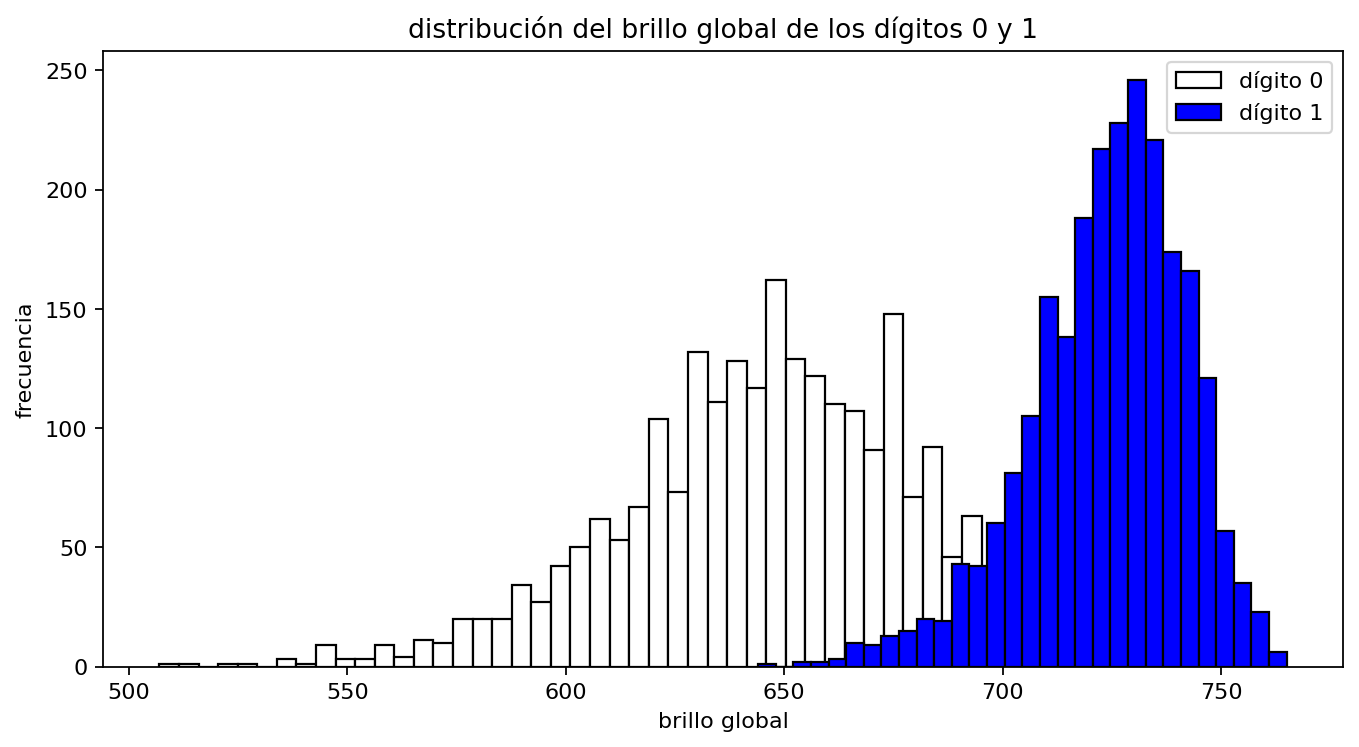

In [ ]:
display(Image(filename=str(figure_dir + 'brillo_global_hist.png'), width=800))

Los histogramas muestran que la característica presenta distribuciones diferentes en ambas clases. Como el dataset contiene la misma cantidad de ceros y unos, esperamos probabilidades a priori similares para las dos clases.

Para modelar $p(x\mid w_i)$ aproximaremos la distribución del brillo global de cada clase mediante una distribución normal o gaussiana.

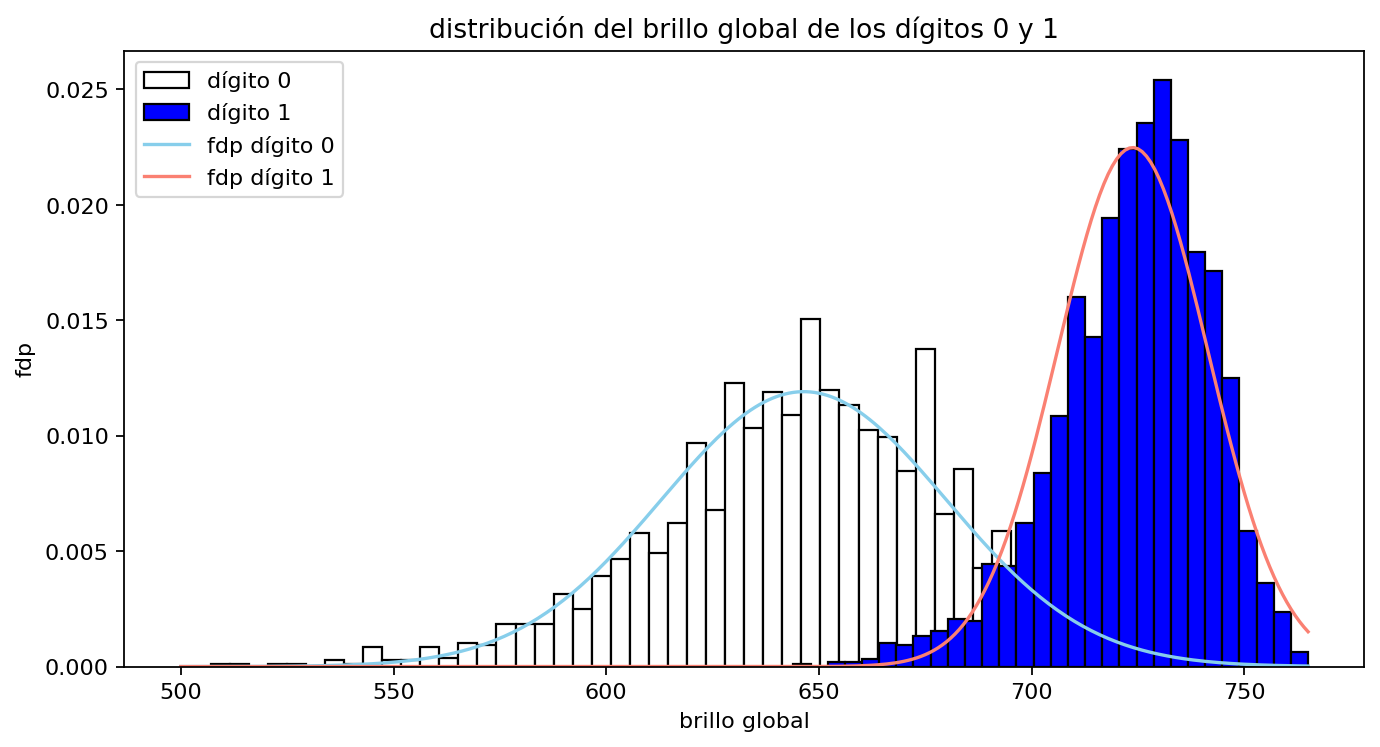

In [ ]:
display(Image(filename=str(figure_dir + 'fdp.png'), width=900))

A partir de $p(x\mid w_i)$ y $P(w_i)$ se obtienen las densidades conjuntas $p(x,w_i)$:

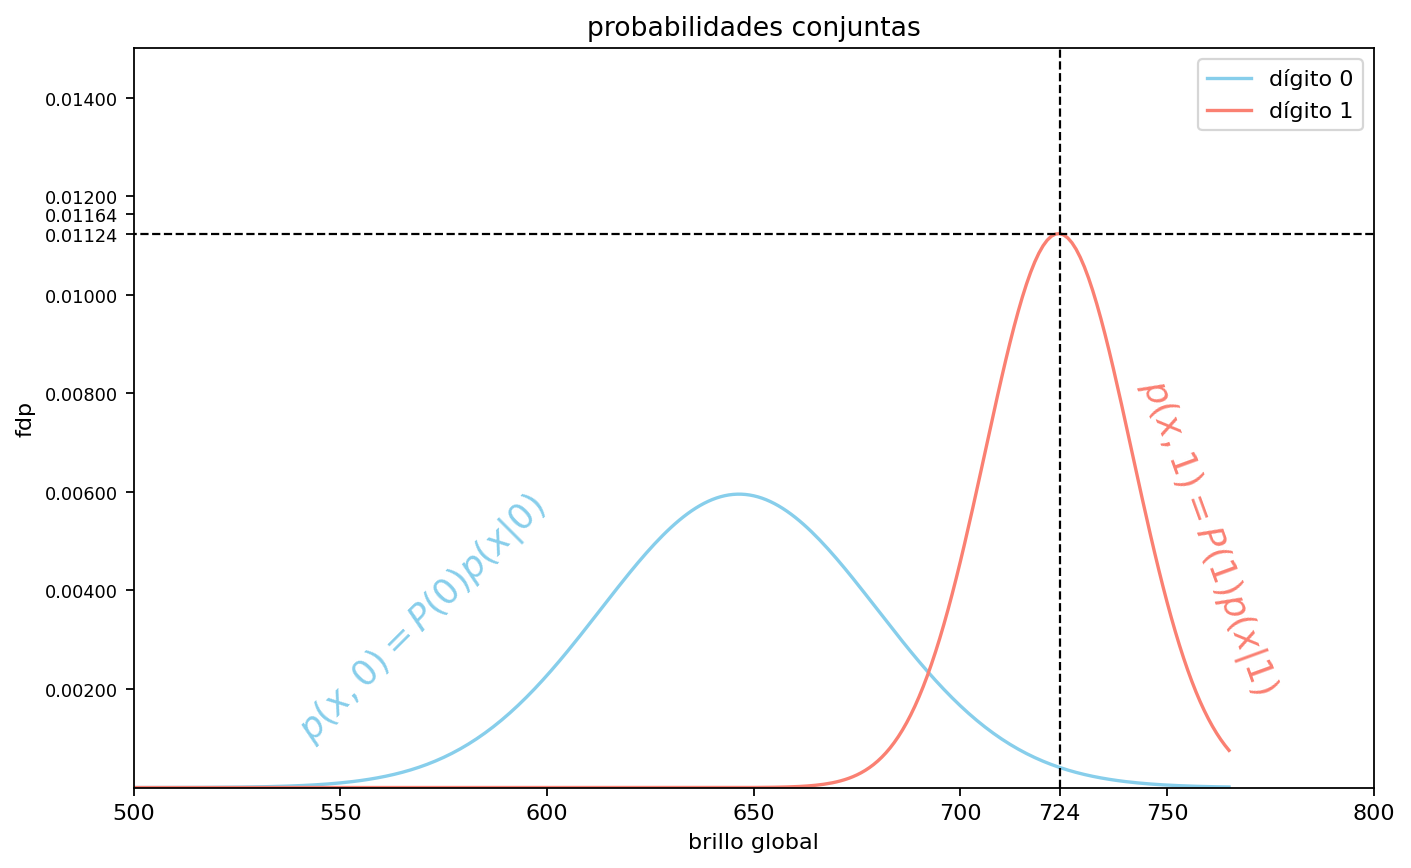

In [ ]:
display(Image(filename=str(figure_dir + 'prob_conjunta.png'), width=1000))

Sumando las densidades conjuntas de las clases se obtiene la densidad marginal $p(x)$:

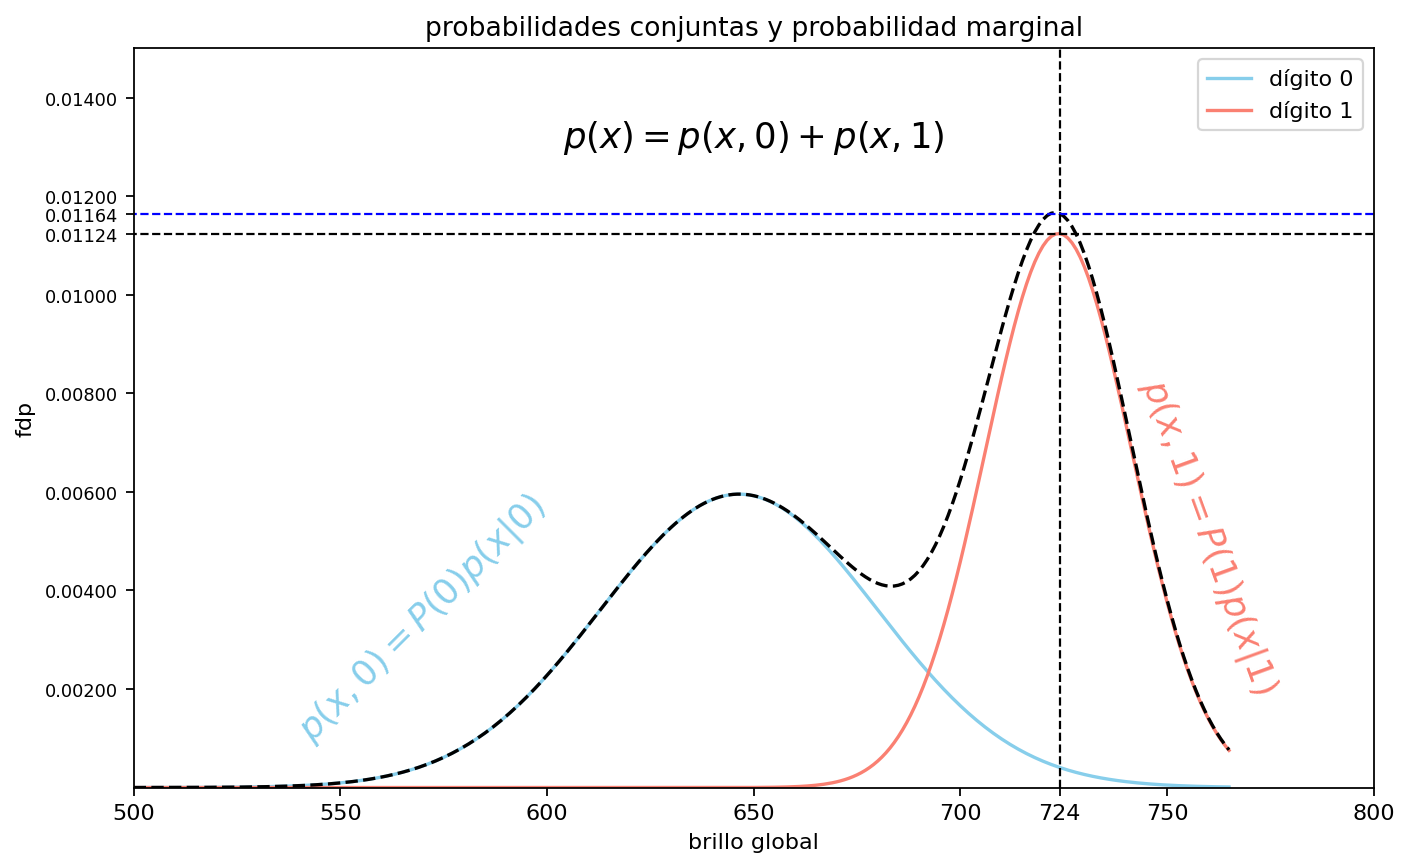

In [ ]:
display(Image(filename=str(figure_dir + 'prob_conjunta_marginal.png'), width=1000))

Finalmente, utilizando la regla de Bayes se obtienen las probabilidades a posteriori:

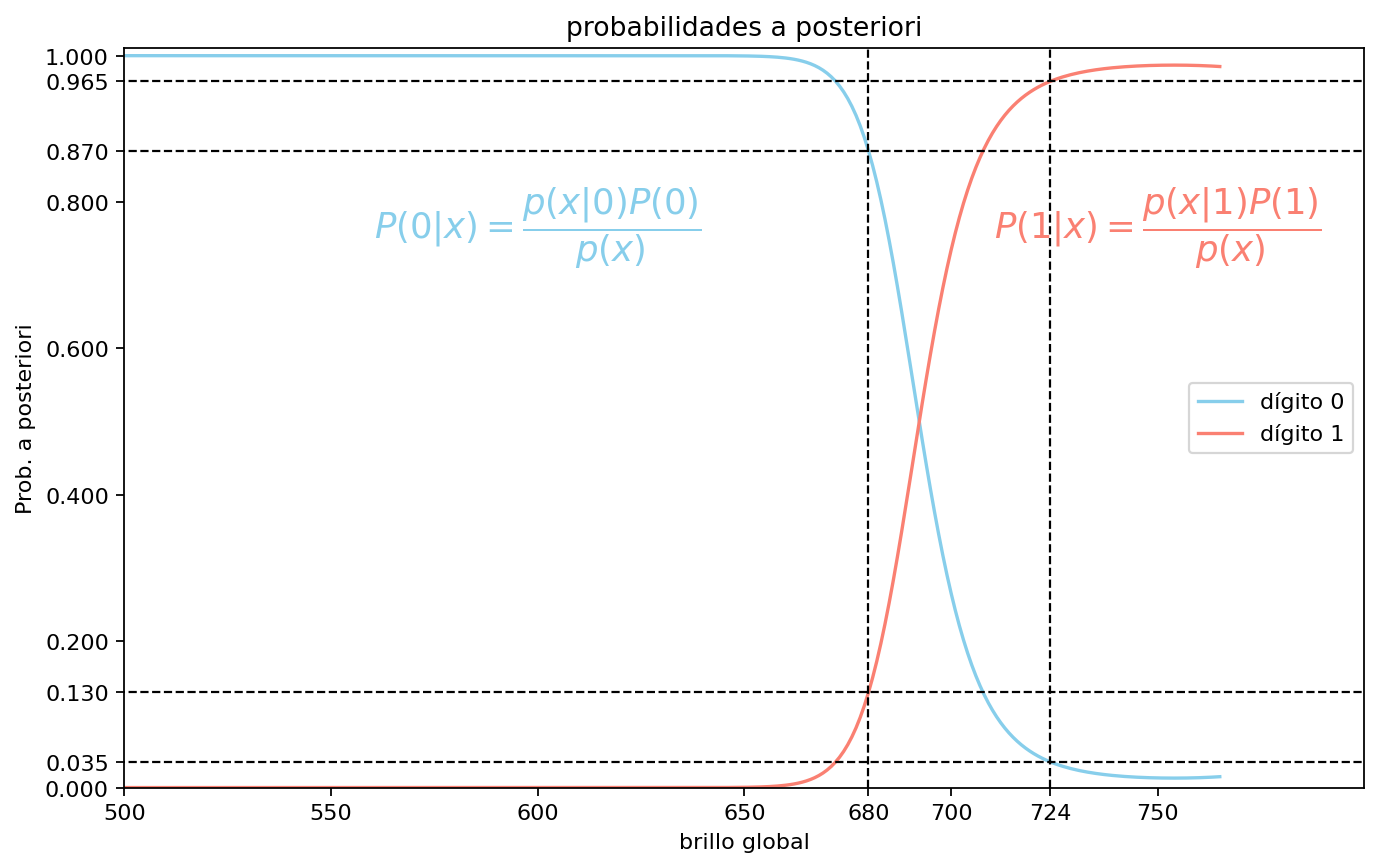

In [ ]:
display(Image(filename=str(figure_dir + 'posteriori.png'), width=900))

## Implementación de la actividad práctica

Reproduzca el análisis anterior a partir del archivo `digitos_0_1.csv`. En cada etapa compare sus resultados con las figuras de referencia.

### 1. Carga y división de los datos

Cargue los datos y sepárelos en entrenamiento y prueba, utilizando un **20% para prueba**, `random_state=0` y `stratify` para preservar la proporción de clases. Separe predictores y etiquetas.

In [9]:
datos = pd.read_csv("./digitos_0_1.csv", sep=",")
datos.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,target
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [10]:
#separamos por predictores y etiquetas, y despues separamos en conjunto de entrenamiento y prueba
X = datos.drop(columns=['target']).to_numpy() #predictores
y = datos['target'].to_numpy() #etiquetas

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

### 2. Procesamiento de datos

Binarice las intensidades utilizando el umbral 127:

- intensidad $>127 \rightarrow 1$;
- intensidad $\le 127 \rightarrow 0$.

Convierta luego los datos a arreglos de NumPy.

In [11]:
#binarizacion 
x_train = (x_train > 127).astype(np.uint8)
x_test = (x_test > 127).astype(np.uint8)

### 3. Visualización de datos

Visualice los primeros 15 dígitos binarizados del conjunto de entrenamiento en una grilla de $3\times5$ y muestre la clase correspondiente a cada imagen. Compare con la Figura 1.

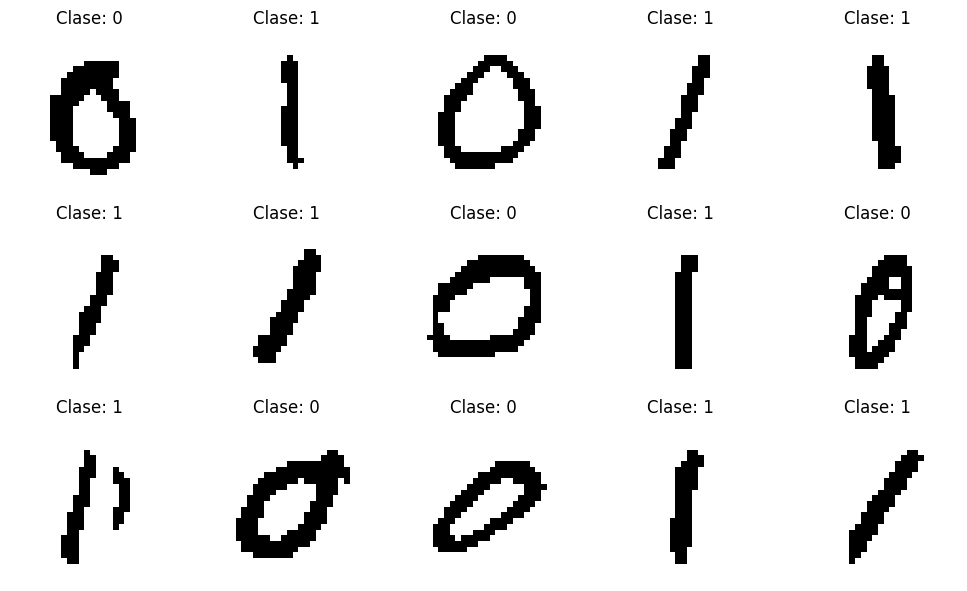

In [12]:
fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for i, ax in enumerate(axes.flat):
    #cada fila de x_train es un vector de 784 valores --> lo reacomodamos a 28x28 para verlo mejor
    imagen= x_train[i].reshape(28,28)
    ax.imshow(imagen, cmap="binary")
    ax.set_title(f"Clase: {y_train[i]}")
    ax.axis('off') #sacamos los ejes 

plt.tight_layout()
plt.show()

**Comparación con Figura 1:**

La grilla obtenida reproduce fielmente la Figura 1: las clases están correctamente asignadas a cada dígito (0 formas cerradas/ovaladas, 1 trazos rectos verticales o diagonales) y se preserva la variabilidad intra-clase esperada (distintas inclinaciones y grosores). Esto confirma que la carga, binarización y reordenamiento de las imágenes (784 a 28×28) se realizaron correctamente

### 4. Cálculo del brillo global

Implemente una función que reciba una imagen binarizada y devuelva la cantidad de píxeles iguales a 0.

Aplique esta función a cada dígito del conjunto de datos para transformarlo a un conjunto de una única característica.

Aplique la función a entrenamiento y prueba.

Puede utilizar la función [np.apply_along_axis](https://numpy.org/doc/stable/reference/generated/numpy.apply_along_axis.html)

Grafique luego un histograma por clase y compárelo con la Figura 2.

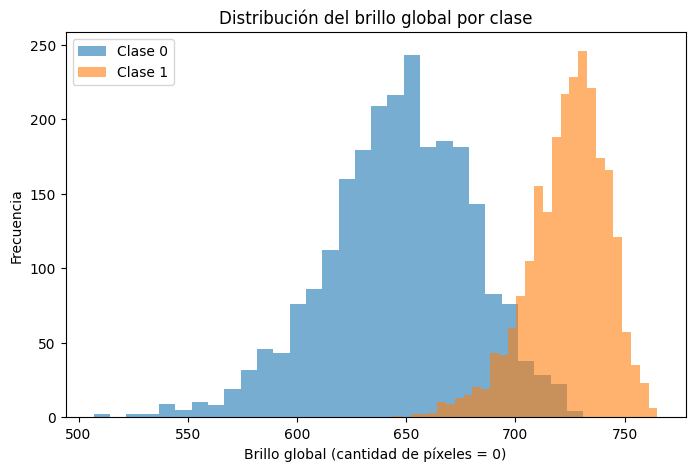

In [13]:
def brillo_global (imagen_binaria):
    """Recibe un vector de 784 valores binarios (0/1) y devuelve la cantidad de píxeles de fondo (valor 0), según:
      x = #{píxeles con valor 0}"""
    return np.sum(imagen_binaria ==0)

#aplicamos la funcion fila por fila a todo el conjunto 
bg_train = np.apply_along_axis(brillo_global, 1, x_train)
bg_test = np.apply_along_axis(brillo_global, 1, x_test)

# histograma por clase, para comparar con la Figura 2
plt.figure(figsize=(8, 5))
plt.hist(bg_train[y_train == 0], bins=30, alpha=0.6, label="Clase 0")
plt.hist(bg_train[y_train == 1], bins=30, alpha=0.6, label="Clase 1")
plt.xlabel("Brillo global (cantidad de píxeles = 0)")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribución del brillo global por clase")
plt.show()

**Comparación con Figura 2:**

El histograma obtenido reproduce la Figura 2: la clase 0 se concentra en valores bajos de brillo global (pico aprox. 630-650) y la clase 1 en valores altos (pico aprox. 725-730), con una zona de solapamiento entre aproximadamente 660 y 710 donde ambas clases coexisten. Esto confirma que el brillo global es una característica informativa para distinguir 0 de 1, aunque no perfectamente separable por sí sola. Las diferencias de estilo (colores, cantidad de bins) no afectan la distribución subyacente, que coincide con la de referencia.

### 5. Probabilidades a priori y parámetros por clase

Calcule $P(w_0)$ y $P(w_1)$ a partir del conjunto de entrenamiento.

Calcule además la media y el desvío estándar del brillo global dentro de cada clase.

In [14]:
# P(w_i): proporción de cada clase en el conjunto de ENTRENAMIENTO 
P_w0 = np.mean(y_train == 0)
P_w1 = np.mean(y_train == 1)

# parámetros de la gaussiana que va a modelar p(x|w_i) en cada clase
mu0, std0 = bg_train[y_train == 0].mean(), bg_train[y_train == 0].std()
mu1, std1 = bg_train[y_train == 1].mean(), bg_train[y_train == 1].std()

print(f"P(w0) = {P_w0:.3f}   P(w1) = {P_w1:.3f}")
print(f"Clase 0 -> mu = {mu0:.2f}, std = {std0:.2f}")
print(f"Clase 1 -> mu = {mu1:.2f}, std = {std1:.2f}")

P(w0) = 0.500   P(w1) = 0.500
Clase 0 -> mu = 646.44, std = 33.50
Clase 1 -> mu = 723.76, std = 17.74


### 6. Modelado de las probabilidades condicionales con distribuciones gaussianas

Para cada clase $w_i$, modele el brillo global como

$$x\mid w_i\sim\mathcal N(\mu_i,\sigma_i^2).$$

Implemente una función para evaluar $p(x\mid w_i)$ utilizando [scipy.stats.norm.pdf](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html). Recuerde que, para una variable continua, la función devuelve una **densidad** y no una probabilidad puntual.

Luego superponga ambas densidades gaussianas sobre los histogramas normalizados (`density=True`) y replique la Figura 3.

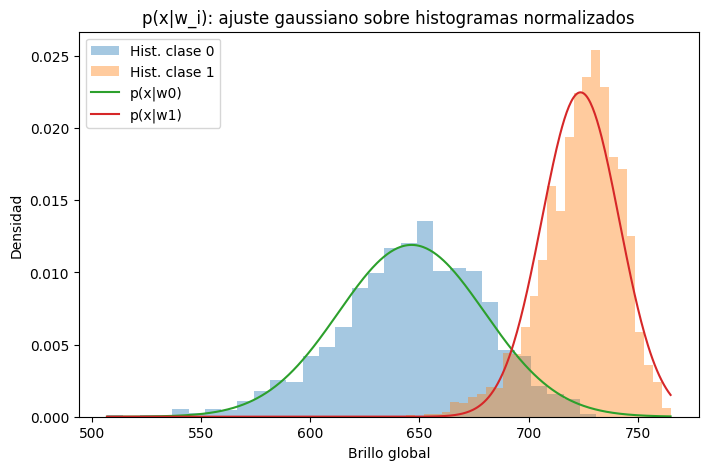

In [15]:
def p_x_dado_clase(x, mu, sigma):
    """Evalúa la densidad gaussiana N(mu, sigma^2) en x. Es una DENSIDAD, no una probabilidad puntual."""
    return stats.norm.pdf(x, loc=mu, scale=sigma)

# rango de valores de x para graficar las curvas
x_vals = np.linspace(bg_train.min(), bg_train.max(), 500)

plt.figure(figsize=(8, 5))
plt.hist(bg_train[y_train == 0], bins=30, density=True, alpha=0.4, label="Hist. clase 0")
plt.hist(bg_train[y_train == 1], bins=30, density=True, alpha=0.4, label="Hist. clase 1")
plt.plot(x_vals, p_x_dado_clase(x_vals, mu0, std0), label="p(x|w0)")
plt.plot(x_vals, p_x_dado_clase(x_vals, mu1, std1), label="p(x|w1)")
plt.xlabel("Brillo global")
plt.ylabel("Densidad")
plt.legend()
plt.title("p(x|w_i): ajuste gaussiano sobre histogramas normalizados")
plt.show()

Las curvas gaussianas p(x | wᵢ) se superponen a los histogramas normalizados de cada clase. La clase 1 se ajusta bien a una campana y la clase 0 es más ancha, ademas su histograma tiene una cola hacia valores bajos que la gaussiana no captura del todo.

### 7. Cálculo de la densidad conjunta

Implemente

$$p(x,w_i)=p(x\mid w_i)P(w_i).$$

Grafique ambas densidades conjuntas y replique la Figura 4.

Verifique el valor para $x=724$ y la clase 1 y márquelo en el gráfico.

p(x=724, w1) = 0.011240


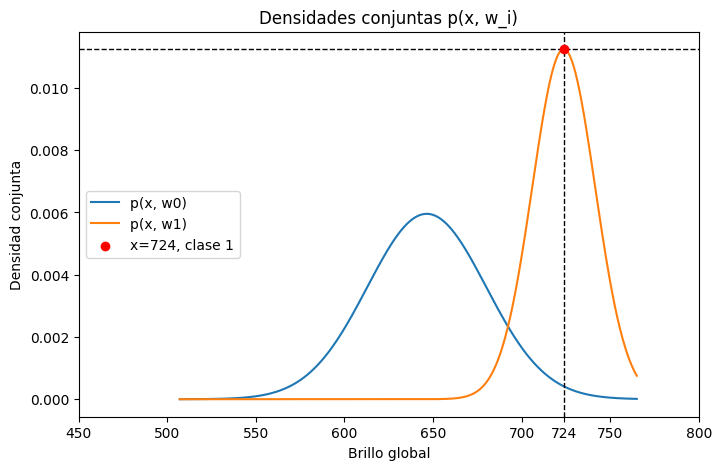

In [16]:
def densidad_conjunta(x, mu, sigma, prior):
    """p(x, w_i) = p(x|w_i) * P(w_i)"""
    return p_x_dado_clase(x, mu, sigma) * prior

joint0_vals = densidad_conjunta(x_vals, mu0, std0, P_w0)
joint1_vals = densidad_conjunta(x_vals, mu1, std1, P_w1)

# verificación pedida: x=724, clase 1
x_check = 724
joint1_check = densidad_conjunta(x_check, mu1, std1, P_w1)
print(f"p(x={x_check}, w1) = {joint1_check:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(x_vals, joint0_vals, label="p(x, w0)")
plt.plot(x_vals, joint1_vals, label="p(x, w1)")
plt.scatter([x_check], [joint1_check], color="red", zorder=5,
            label=f"x={x_check}, clase 1")
plt.axvline(x=x_check, color='black', linestyle='--', linewidth=1)
plt.axhline(y=joint1_check, color='black', linestyle='--', linewidth=1)
plt.xticks(sorted(set(list(plt.xticks()[0]) + [x_check])))
plt.xlabel("Brillo global")
plt.ylabel("Densidad conjunta")
plt.legend()
plt.title("Densidades conjuntas p(x, w_i)")
plt.show()

En x = 724, p(x,w₁) = 0,011240. Como este valor está muy cerca de μ₁ ≈ 723,76 (la media de la clase 1), el punto evaluado queda prácticamente en el máximo de esa curva, que por definición de la gaussiana se alcanza en x = μᵢ. Además, se observa que las densidades conjuntas tienen la misma forma que p(x|wᵢ) pero con la altura reducida (ya que ambos priors son 0,5, el factor de escala es el mismo para las dos clases)

### 8. Cálculo de la densidad marginal

Implemente la suma sobre clases:

$$p(x)=\sum_i p(x\mid w_i)P(w_i).$$

Verifique el valor para $x=724$ y grafique la marginal junto con las densidades conjuntas, replicando la Figura 5.

p(x=724) = 0.011649


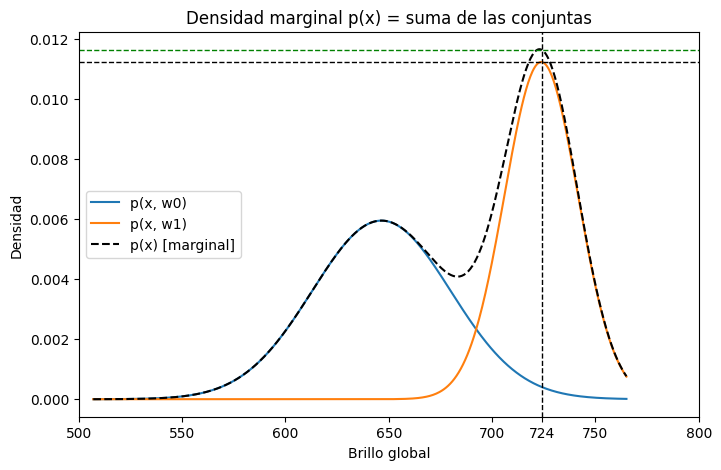

In [17]:
def densidad_marginal(x, mu0, std0, P0, mu1, std1, P1):
    """p(x) = p(x,w0) + p(x,w1), suma sobre todas las clases"""
    return densidad_conjunta(x, mu0, std0, P0) + densidad_conjunta(x, mu1, std1, P1)

marginal_vals = densidad_marginal(x_vals, mu0, std0, P_w0, mu1, std1, P_w1)
marginal_check = densidad_marginal(x_check, mu0, std0, P_w0, mu1, std1, P_w1)
print(f"p(x={x_check}) = {marginal_check:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(x_vals, joint0_vals, label="p(x, w0)")
plt.plot(x_vals, joint1_vals, label="p(x, w1)")
plt.plot(x_vals, marginal_vals, "k--", label="p(x) [marginal]")
plt.axvline(x=x_check, color='black', linestyle='--', linewidth=1)
plt.axhline(y=joint1_check, color='black', linestyle='--', linewidth=1)
plt.axhline(y=marginal_check, color='green', linestyle='--', linewidth=1)
plt.xticks(sorted(set(list(plt.xticks()[0]) + [x_check])))

plt.xlim(500, 800)

plt.xlabel("Brillo global")
plt.ylabel("Densidad")
plt.legend()
plt.title("Densidad marginal p(x) = suma de las conjuntas")
plt.show()

En la grafica se observa que x = 724, p(x) = 0,011649, apenas mayor que p(x, w₁), por lo que podemos concluir que la clase 0 aporta muy poco en ese punto.

### 9. Cálculo de las probabilidades a posteriori

Implemente la regla de Bayes para calcular $P(w_i\mid x)$ para todas las clases.

Verifique los resultados para $x=680$ y $x=724$ y replique la Figura 6.

x=680: P(w0|x)=0.8702  P(w1|x)=0.1298
x=724: P(w0|x)=0.0351  P(w1|x)=0.9649


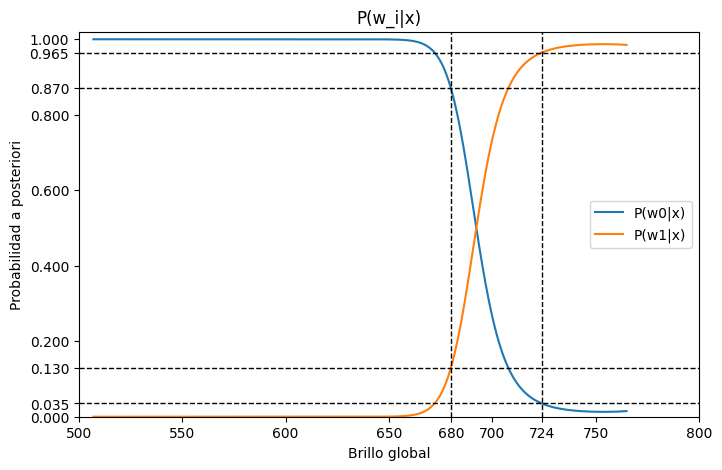

In [18]:
def posteriori(x, mu0, std0, P0, mu1, std1, P1):
    """P(w_i|x) = p(x,w_i) / p(x), regla de Bayes"""
    j0 = densidad_conjunta(x, mu0, std0, P0)
    j1 = densidad_conjunta(x, mu1, std1, P1)
    marg = j0 + j1
    return j0 / marg, j1 / marg

x_marcados = [680, 724]
yticks_extra = []

for x_test_val in x_marcados:
    post0, post1 = posteriori(x_test_val, mu0, std0, P_w0, mu1, std1, P_w1)
    print(f"x={x_test_val}: P(w0|x)={post0:.4f}  P(w1|x)={post1:.4f}")
    yticks_extra += [post0, post1]

post0_vals, post1_vals = posteriori(x_vals, mu0, std0, P_w0, mu1, std1, P_w1)
plt.figure(figsize=(8, 5))
plt.plot(x_vals, post0_vals, label="P(w0|x)")
plt.plot(x_vals, post1_vals, label="P(w1|x)")
plt.axvline(x=x_marcados[0], color='black', linestyle='--', linewidth=1)
plt.axvline(x=x_marcados[1], color='black', linestyle='--', linewidth=1)
plt.axhline(y=yticks_extra[0], color='black', linestyle='--', linewidth=1)
plt.axhline(y=yticks_extra[1], color='black', linestyle='--', linewidth=1)
plt.axhline(y=yticks_extra[2], color='black', linestyle='--', linewidth=1)
plt.axhline(y=yticks_extra[3], color='black', linestyle='--', linewidth=1)

xt = sorted(set(list(plt.xticks()[0]) + x_marcados))
yt = sorted(set(list(plt.yticks()[0]) + yticks_extra))
plt.xticks(xt)
plt.yticks(yt, [f"{t:.3f}" for t in yt])
plt.xlim(500, 800)
plt.ylim(0, 1.02)

plt.xlabel("Brillo global")
plt.ylabel("Probabilidad a posteriori")
plt.legend()
plt.title("P(w_i|x)")
plt.show()

En la grafica las probabilidades posteriori toman valores entre 0 y 1 y suman 1 en cada punto. Además, se observa que en x = 680, P(w₀|x) = 0,8702 y P(w₁|x) = 0,1298, por lo tanto predomina la clase 0, mientras que en x = 724 es al reves. El punto donde ambas curvas se cruzan es donde cambia la decisión del clasificador.

### 10. Regla MAP y clasificación

Para clasificar no es necesario calcular explícitamente $p(x)$, porque el denominador es el mismo para todas las clases. Compruebe que

$$\arg\max_i P(w_i\mid x)=\arg\max_i p(x\mid w_i)P(w_i).$$

Obtenga las predicciones sobre el conjunto de prueba y calcule la exactitud (*accuracy*).

In [19]:
def clasificar_map(x_vals, mu0, std0, P0, mu1, std1, P1):
    """
    No hace falta calcular p(x): como es el mismo denominador para
    todas las clases, comparar p(x,w_i) alcanza para decidir el argmax.
    """
    j0 = densidad_conjunta(x_vals, mu0, std0, P0)
    j1 = densidad_conjunta(x_vals, mu1, std1, P1)
    return (j1 > j0).astype(int)  # 1 si gana la clase 1, 0 si gana la clase 0

y_pred_manual = clasificar_map(bg_test, mu0, std0, P_w0, mu1, std1, P_w1)
acc_manual = accuracy_score(y_test, y_pred_manual)
print(f"accuracy del clasificador manual: {acc_manual:.4f}")

accuracy del clasificador manual: 0.9333


In [31]:
def clasificar_posteriori(x, mu0, std0, P0, mu1, std1, P1):
    """Decide usando las probabilidades a posteriori P(w_i|x), con p(x) incluida."""
    post0, post1 = posteriori(x, mu0, std0, P0, mu1, std1, P1)
    return (post1 > post0).astype(int)

y_pred_post = clasificar_posteriori(bg_test, mu0, std0, P_w0, mu1, std1, P_w1)

print("Decisiones idénticas:", np.array_equal(y_pred_post, y_pred_manual))
print("Instancias donde difieren:", np.sum(y_pred_post != y_pred_manual))
print(f"Accuracy con posteriori: {accuracy_score(y_test, y_pred_post):.4f}")
print(f"Accuracy con MAP:        {accuracy_score(y_test, y_pred_manual):.4f}")

Decisiones idénticas: True
Instancias donde difieren: 0
Accuracy con posteriori: 0.9333
Accuracy con MAP:        0.9333


Ambas reglas producen exactamente las mismas predicciones sobre el conjunto de prueba, lo que verifica que p(x) no influye en la decisión.

# 4. Comparación con Scikit-Learn

Entrene [GaussianNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html#sklearn.naive_bayes.GaussianNB) utilizando solamente el brillo global. Compare las predicciones y el desempeño con la implementación manual.

Luego inspeccione `class_prior_`, `theta_` y `var_` del objeto entrenado e interprete qué cantidad del desarrollo anterior representa cada atributo.

In [20]:
gnb = GaussianNB()
gnb.fit(bg_train.reshape(-1, 1), y_train)
y_pred = gnb.predict(bg_test.reshape(-1, 1))
acc_sklearn = accuracy_score(y_test, y_pred)
print(f"Accuracy de sklearn: {acc_sklearn:.4f}")
print(f"Accuracy manual: {acc_manual:.4f}")

# --- Comparación de predicciones ---
coinciden = np.mean(y_pred == y_pred_manual)
print(f"Coincidencia entre predicciones: {coinciden:.4%}")
print("Instancias donde difieren:", np.sum(y_pred != y_pred_manual))

Accuracy de sklearn: 0.9333
Accuracy manual: 0.9333
Coincidencia entre predicciones: 100.0000%
Instancias donde difieren: 0


Ambas implementaciones dan las mismas predicciones (100 % de coincidencia) y el mismo accuracy, ya que GaussianNB modela cada clase con una gaussiana estimada por máxima verosimilitud y aplica la regla de Bayes, igual que la implementación manual. Por lo tanto, en este conjunto de prueba se confirma que la implementación manual es correcta.

In [21]:
# Comparación de los parámetros manuales con los aprendidos por sklearn
comparacion = pd.DataFrame([
    {"Clase": 0, "Parámetro": "P(w_i)", "Manual": P_w0, "sklearn": gnb.class_prior_[0]},
    {"Clase": 1, "Parámetro": "P(w_i)", "Manual": P_w1, "sklearn": gnb.class_prior_[1]},

    {"Clase": 0, "Parámetro": "mu_i", "Manual": mu0, "sklearn": gnb.theta_[0, 0]},
    {"Clase": 1, "Parámetro": "mu_i", "Manual": mu1, "sklearn": gnb.theta_[1, 0]},

    {"Clase": 0, "Parámetro": "sigma_i^2", "Manual": std0**2, "sklearn": gnb.var_[0, 0]},
    {"Clase": 1, "Parámetro": "sigma_i^2", "Manual": std1**2, "sklearn": gnb.var_[1, 0]},
])

comparacion["Diferencia"] = comparacion["sklearn"] - comparacion["Manual"]
display(comparacion.round(6))

,Clase,Parámetro,Manual,sklearn,Diferencia
0,0,P(w_i),0.500000,0.500000,0.000000
1,1,P(w_i),0.500000,0.500000,0.000000
2,0,mu_i,646.443333,646.443333,0.000000
3,1,mu_i,723.755833,723.755833,0.000000
4,0,sigma_i^2,1122.382622,1122.382624,0.000002
5,1,sigma_i^2,314.862049,314.862052,0.000002


Al inspeccionar `class_prior_`, `theta_` y `var_` del objeto entrenado se puede ver que corresponden en el desarrollo manual a $P(w_i)$, la media $(mu_i)$ y varianza $(std_i^2)$ respectivamente, donde i = 0,1.

# 5. Del clasificador de Bayes al clasificador Naive Bayes

Hasta ahora se utilizó una única característica:

$$x=\text{brillo global}.$$

Por eso no fue necesario realizar ningún supuesto sobre relaciones entre características. Al representar una muestra mediante varias características,

$$\mathbf{x}=(x_1,x_2,\ldots,x_d),$$

sería necesario estimar la densidad conjunta

$$p(x_1,x_2,\ldots,x_d\mid w_i).$$

Naive Bayes simplifica este problema suponiendo **independencia condicional dada la clase**:

$$p(x_1,x_2,\ldots,x_d\mid w_i)=\prod_{j=1}^{d}p(x_j\mid w_i).$$

Trabajaremos ahora con dos características extraídas de cada imagen:

1. brillo global;
2. cantidad de transiciones entre píxeles vecinos horizontales y verticales, utilizada como una medida sencilla de bordes/complejidad de la forma.

### 1. Cargar y dividir los datos

Vuelva a cargar el CSV, separe predictores y etiquetas y realice una partición 80/20 con `random_state=0` y `stratify=y`.

In [22]:
datos_1 = pd.read_csv("./digitos_0_1.csv", sep=",")

#separamos por predictores y etiquetas, y despues separamos en conjunto de entrenamiento y prueba
X1 = datos_1.drop(columns=['target']).to_numpy() #predictores
y1 = datos_1['target'].to_numpy() #etiquetas

x_train_1, x_test_1, y_train_1, y_test_1 = train_test_split(X1, y1, test_size=0.2, random_state=0, stratify=y1)

### 2. Binarizar y calcular las dos características

Binarice las imágenes usando el mismo umbral.

Implemente las funciones necesarias para obtener el brillo global y la cantidad de transiciones entre píxeles vecinos.

Construya matrices de características de dos columnas para entrenamiento y prueba.

In [23]:
#binarizacion 
x_train_1 = (x_train_1 > 127).astype(np.uint8)
x_test_1 = (x_test_1 > 127).astype(np.uint8)

In [24]:
#aplicamos la funcion fila por fila a todo el conjunto 
bg_train_1 = np.apply_along_axis(brillo_global, 1, x_train_1)
bg_test_1 = np.apply_along_axis(brillo_global, 1, x_test_1)

#cantidad de transiciones de 0 a 1 y de 1 a 0
def transiciones(imagen_binaria):
    """
    Recibe un vector de 784 píxeles binarios y cuenta las transiciones
    horizontales y verticales en la matriz.
    """
    img_2d = imagen_binaria.reshape(28, 28)
    trans_horiz = np.sum(img_2d[:, :-1] != img_2d[:, 1:])
    trans_vert = np.sum(img_2d[:-1, :] != img_2d[1:, :])
    return trans_horiz + trans_vert

#aplicamos la funcion fila por fila a todo el conjunto 
trans_train = np.apply_along_axis(transiciones, 1, x_train_1)
trans_test = np.apply_along_axis(transiciones, 1, x_test_1)


In [25]:
# Matrices de características: [brillo global, transiciones]
X_train_1 = np.column_stack((bg_train_1, trans_train))
X_test_1 = np.column_stack((bg_test_1, trans_test))

matriz = pd.DataFrame(
    X_train_1,
    columns=["Brillo global", "Transiciones"]
)

display(matriz.head())
print("X_train_1:", X_train_1.shape)
print("X_test_1:", X_test_1.shape)

,Brillo global,Transiciones
0,628,112
1,734,50
2,651,130
3,729,58
4,711,52


X_train_1: (4800, 2)
X_test_1: (1200, 2)


### 3. Entrenamiento y evaluación

Entrene `GaussianNB` con las dos características. Obtenga las predicciones, la exactitud, la matriz de confusión y el `classification_report`. Investigue que devuelve `classification_report`

In [26]:
# Entrenar GaussianNB con las dos características
gnb_2 = GaussianNB()
gnb_2.fit(X_train_1, y_train_1)

# Predicciones y métricas sobre el conjunto de prueba
y_pred_2 = gnb_2.predict(X_test_1)
acc_2 = accuracy_score(y_test_1, y_pred_2)
matriz_confusion = confusion_matrix(y_test_1, y_pred_2, labels=[0, 1])

print(f"Predicciones: {y_pred_2}")
print(f"Accuracy: {acc_2:.4f}")
print("Matriz de confusión (filas = clase real, columnas = predicha):")
print(matriz_confusion)
print("\nInforme de clasificación:")
print(classification_report(
    y_test_1,
    y_pred_2,
    labels=[0, 1],
    target_names=["Clase 0", "Clase 1"],
    zero_division=0
))

Predicciones: [1 1 1 ... 0 0 1]
Accuracy: 0.9967
Matriz de confusión (filas = clase real, columnas = predicha):
[[600   0]
 [  4 596]]

Informe de clasificación:
              precision    recall  f1-score   support

     Clase 0       0.99      1.00      1.00       600
     Clase 1       1.00      0.99      1.00       600

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



Al agregar la cantidad de transiciones, el modelo cuenta con información que el brillo global no aporta por sí solo, donde los brillos de ambas clases se solapan, las transiciones sí las separan. Por eso la accuracy subió de 0,9333 a 0,9967, es decir, de varios errores paso a tener 4 sobre 1200 muestras.

Como se puede observar `Classification_report` devuelve, por clase, precision, recall y f1-score, además de accuracy global. El promedio macro calcula la media simple entre clases, dándole el mismo peso a cada una sin importar cuántas muestras tenga. El promedio weighted pondera cada clase según su support (cantidad real de muestras), por lo que en un dataset desbalanceado el weighted se acerca más al desempeño sobre la clase mayoritaria.

### 4. Visualización de la clasificación

Realice un diagrama de dispersión sobre el conjunto de prueba:

- eje X: brillo global;
- eje Y: cantidad de transiciones/bordes;
- color: clase predicha.

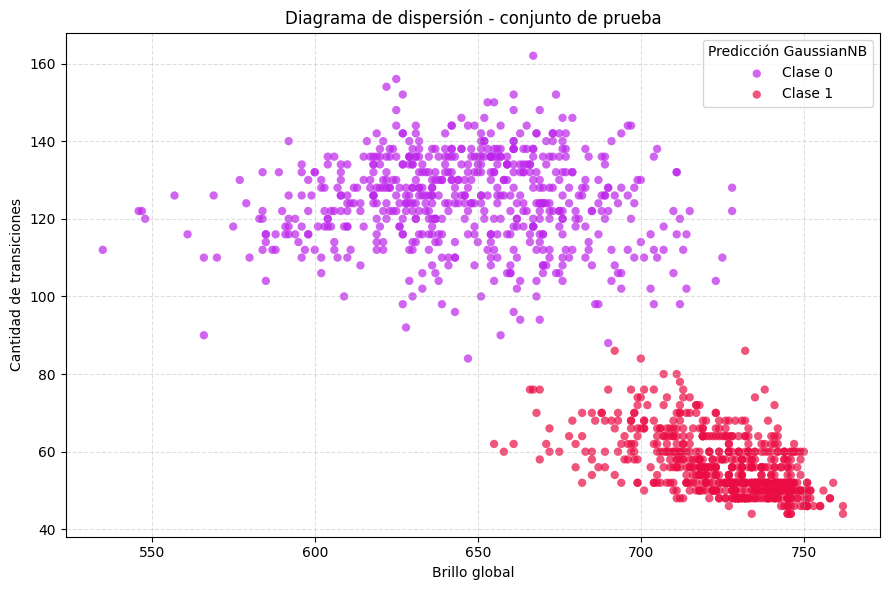

In [27]:
plt.figure(figsize=(9, 6))

for clase, color in [(0, "#bd25eb"), (1, "#ea0c43")]:
    mascara = y_pred_2 == clase
    plt.scatter(
        X_test_1[mascara, 0],
        X_test_1[mascara, 1],
        color=color,
        label=f"Clase {clase}",
        alpha=0.7,
        edgecolors="none",
    )

plt.title("Diagrama de dispersión - conjunto de prueba")
plt.xlabel("Brillo global")
plt.ylabel("Cantidad de transiciones")
plt.legend(title="Predicción GaussianNB")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### 5. Fronteras de decisión

Grafique las regiones de decisión del clasificador sobre el plano de las dos características. Utilice la función provista a continuación y superponga los datos de prueba coloreados según su **clase real**.

In [28]:
def plot_decision_regions(model, X, y, x_label='Feature 1', y_label='Feature 2', title='Decision regions'):
    """Plot 2D decision regions and true class labels."""
    x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
    y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5

    x_values = np.linspace(x_min, x_max, 300)
    y_values = np.linspace(y_min, y_max, 300)
    xx, yy = np.meshgrid(x_values, y_values)

    grid = np.column_stack((xx.ravel(), yy.ravel()))
    zz = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, zz, alpha=0.35, cmap=plt.cm.coolwarm)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='black', cmap=plt.cm.coolwarm)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.colorbar(scatter, label='Clase real')
    plt.show()

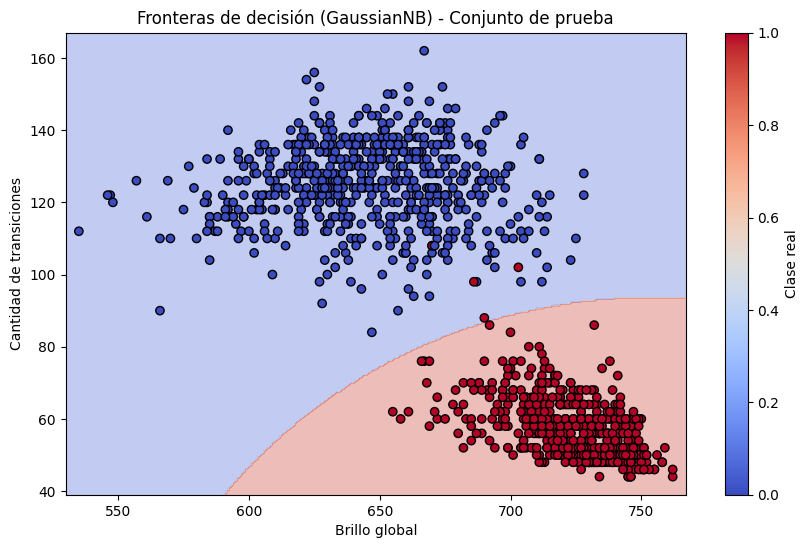

In [29]:
plot_decision_regions(
    model=gnb_2,
    X=X_test_1,
    y=y_test_1,
    x_label="Brillo global",
    y_label="Cantidad de transiciones",
    title="Fronteras de decisión (GaussianNB) - Conjunto de prueba",
)

En la gráfica se observa que la frontera de decisión no es una recta sino una curva, debido a que cada clase tiene una varianza distinta. Asimismo, se identifican los errores de clasificación, que se ubican cerca de esa frontera.

### 6. ¿Qué tan razonable es el supuesto *Naive*?

Analice la relación entre las dos características **dentro de cada clase**. Como diagnóstico sencillo, calcule el coeficiente de correlación lineal por clase.

> Importante: correlación nula **no demuestra independencia**. Sin embargo, una correlación claramente distinta de cero sí evidencia dependencia lineal.

En este ejemplo, ¿las dos características parecen cumplir exactamente la independencia condicional?

In [30]:
df_train = pd.DataFrame(X_train_1, columns=["Brillo", "Transiciones"])
df_train["target"] = y_train_1

# Correlación lineal para la Clase 0
corr_clase_0 = df_train[df_train["target"] == 0][
    ["Brillo", "Transiciones"]
].corr().iloc[0, 1]

# Correlación lineal para la Clase 1
corr_clase_1 = df_train[df_train["target"] == 1][
    ["Brillo", "Transiciones"]
].corr().iloc[0, 1]

print(f"Correlación en Clase 0: {corr_clase_0:.4f}")
print(f"Correlación en Clase 1: {corr_clase_1:.4f}")

Correlación en Clase 0: 0.0155
Correlación en Clase 1: -0.5403


Las dos caracteristicas no cumplen de forma exacta la independencia condicional, debido a que la presencia de una correlación $r = -0.5403$ en la Clase 1, muestra evidencia directa de dependencia lineal condicional entre el brillo global y las transiciones para este dígito. En la clase 0, la correlación es practicamente nula ($r = 0.0155$), por lo que podemos decir que ambas caracteristicas parecen comportarse de forma linealmente independiente. Sin embargo, una correlación no nula no prueba independencia, ya que podría existir una relacion no lineal que este coeficiente no detecta. 

La dependencia observada se explica ya que ambas características se calculan a partir de los mismos píxeles de la imagen, por lo que es esperable que estén relacionadas.

A pesar, de que no se cumple el supuesto en la clase 1, el clasificador obtiene un accuracy de 0,9967. Esto se debe a que, para clasificar, solo importa qué clase tiene mayor probabilidad a posteriori y no el valor exacto de esas probabilidades.